### ตัวอย่างโปรแกรมและการใช้งาน Gradient Descent (การเคลื่อนลงด้วยความชัน)

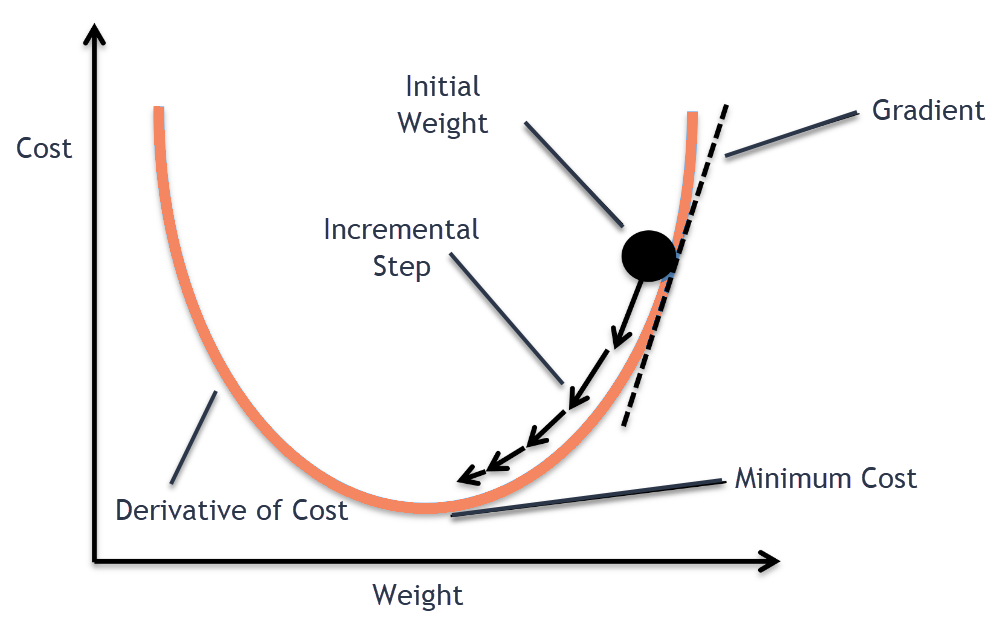

Gradient Descent
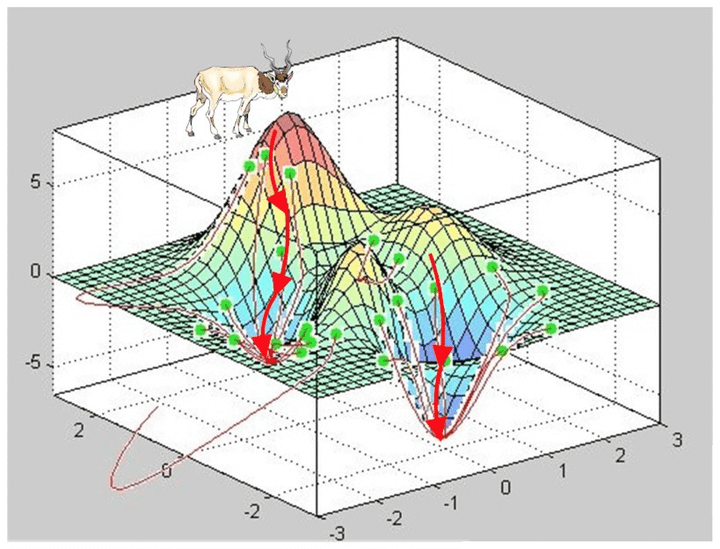

Gradient Descent คือ อัลกอริทึมที่ใช้สำหรับการหา "จุดที่ต่ำที่สุดของฟังก์ชัน (Cost Function)" เพื่อปรับจูนค่า parameter เช่น ถ้าเป็น Linear Regression คือ ความชัน ($\theta_1$) และ จุดตัดแกน y ($\theta_0$) เพื่อให้สามารถทำนายผลลัพธ์ได้แม่นยำที่สุด

โดยองค์ประกอบสำคัญของ Gradient Descent จะประกอบด้วย
1. Cost Function ($J$) : เป็นฟังก์ชันสำหรับการความผิดพลาดของโมเดล เช่น Linear Regression จะเป็น MSE เป็นต้น
2. Weights หรือ ค่าน้ำหนัก : ค่าพารามิเตอร์ที่โมเดลใช้เรียนรู้และปรับเปลี่ยนเพื่อลดข้อผิดพลาดในการทำนาย เช่น $w$, $b$
3. Gradient : ความชันของ Cost Function 
4. Learing Rate ($\alpha$) : อัตราการเรียนรู้ของโมเดล

สมการทางคณิตศาสตร์ของ Gradient Descent

$\theta_{t+1}=\theta_t - \alpha\nabla{J(\theta_t)}$

- $\theta_{t+1}$ : ค่าพารามิเตอร์ใหม่
- $t$ : ขั้นตอน ณ ปัจจุบัน
- $\alpha$ : อัตราการเรียนรู้ (Learning Rate)
- $\nabla{J(\theta_t)}$ : Gradient 

ตัวอย่างเช่น Cost Function ของ Linear Regression คือ $MSE = \frac{1}{n}\sum_{i=1}^{n}{(\hat{y_i}-y_i)^2}$

เราสามารถหา Gradient ของ MSE ได้เป็น 
$\partial w = \frac{2}{n}\sum^{n}_{i=1}{(\hat{y_i}-y_i)^2 \cdot X}$ และ $\partial b = \frac{2}{n}\sum^{n}_{i=1}{(\hat{y_i}-y_i)^2}$ เป็นต้น

In [1]:
#เริ่มต้น Download เครื่องมือที่จำเป็นเช่น Numpy สำหรับการคำนวณทางคณิตศาสตร์
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


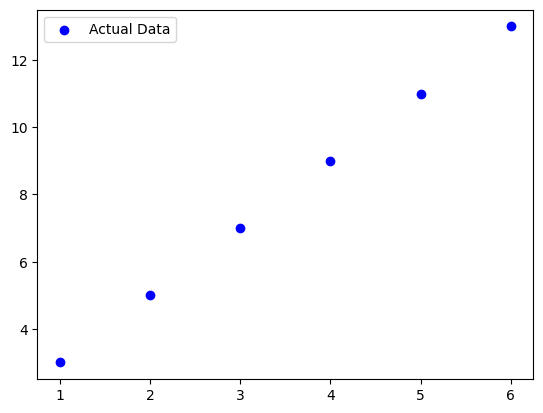

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#1. ข้อมูลจำลอง
#X = ชั่วโมงการอ่านหนังสือ Y = คะแนนการอ่านหนังสือ
X = np.array([1,2,3,4,5,6])
Y = np.array([3,5,7,9,11,13])

plt.scatter(X, Y,color="blue",label="Actual Data")
plt.legend()


In [3]:
#2. กำหนดพารามิเตอร์เริ่มต้น
w = 0.0 # ความชันเริ่มต้น
b = 0.0 # จุดตัดแกนเริ่มต้น
learning_rate = 0.01 # อัตราการเรียนรู้ 
epochs = 1000

n = len(X) 

In [4]:
#3. เริ่มต้นกระบวนการ Gradient Descent 
for i in range(epochs):
    # Linear Regression สมการการถดถอยเชิงเส้น
    y_pred = (w*X)+b
    # Cost Function สมการสำหรับการตรวจสอบค่าความผิด
    cost = (1/n) * np.sum((y_pred - Y)**2)
    # Gradient คำนวณความชัน
    dw = (2/n) * np.sum((y_pred - Y) * X)
    db = (2/n) * np.sum((y_pred - Y))
    # อัพเดทค่าน้ำหนัก 
    w = w - (learning_rate * dw)
    b = b - (learning_rate * db)

    if (i+1) % 100 == 0:
        print(f"รอบที่ {i+1}: Cost = {cost:.4f}, w = {w}, b = {b:.4f}")

print(w)

รอบที่ 100: Cost = 0.0238, w = 2.0818800902162136, b = 0.6495
รอบที่ 200: Cost = 0.0115, w = 2.056806143656631, b = 0.7568
รอบที่ 300: Cost = 0.0055, w = 2.0394105325069463, b = 0.8313
รอบที่ 400: Cost = 0.0027, w = 2.0273419382570563, b = 0.8829
รอบที่ 500: Cost = 0.0013, w = 2.0189690811084806, b = 0.9188
รอบที่ 600: Cost = 0.0006, w = 2.013160224221019, b = 0.9437
รอบที่ 700: Cost = 0.0003, w = 2.009130199852963, b = 0.9609
รอบที่ 800: Cost = 0.0001, w = 2.0063342803249435, b = 0.9729
รอบที่ 900: Cost = 0.0001, w = 2.004394548627755, b = 0.9812
รอบที่ 1000: Cost = 0.0000, w = 2.0030488163849736, b = 0.9869
2.0030488163849736


การ Train เสร็จแล้ว !
สมการการถดถอยเชิงเส้น คือ y = 2.0030x + 0.9869


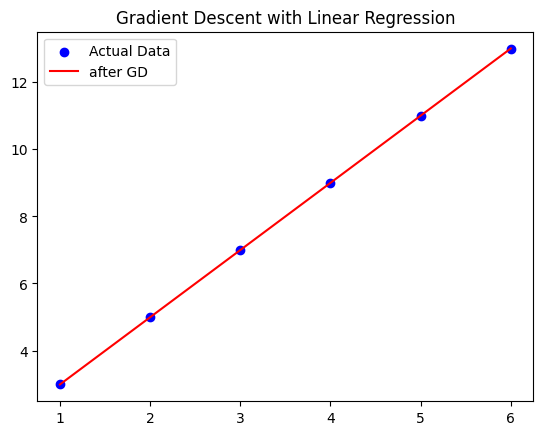

In [5]:
#4. แสดงผล Output ที่ได้ออกมา
y_output = (w * X) + b
print("การ Train เสร็จแล้ว !")
print(f"สมการการถดถอยเชิงเส้น คือ y = {w:.4f}x + {b:.4f}")
plt.title("Gradient Descent with Linear Regression")
plt.scatter(X, Y,color="blue", label='Actual Data')
plt.plot(X, y_output, color="red", label='after GD')
plt.legend()

สรุปผลลัพธ์ มีการใช้งาน Gradient Descent เพื่อหาค่าพารามิเตอร์ที่เหมาะสมที่สุดสำหรับชุดข้อมูล X, Y โดยได้มีการลองพล็อตกราฟแล้วพบว่า โมเดล Linear Regression เหมาะสมจึงมีการใช้งาน พบว่าสมการเส้นตรงที่ได้คือ $y=2.003x+0.9869$ ที่เหมาะสมที่สุดในชุดข้อมูลนี้